In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load and :
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# clean data
df["Age"].fillna(df["Age"].mean(),inplace=True) # aduset the missing value of age
df.drop(columns=["Cabin"],inplace=True) # cabin collumn ko hata do kyuki vo bhut jayda missing th or usko itna importance bh nhi diya jata
df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True) #  person kis port sai pick hua tha uskai aas pass kai log ka dekh kr pachan lo
df["Sex"]=df["Sex"].map({"male":0,"female":1}) # male or female ko number assgn kro kyuki model sirf number samajta h
df["Embarked"]=df["Embarked"].map({"S":0,"C":1,"Q":2})

feactures=["Pclass","Sex","Age","SibSp","Parch","Fare","Embarked"]
X=df[feactures].values
y=df["Survived"].values

# Train Text Split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)
# Convert to PyTorch tensor
X_train_t=torch.FloatTensor(X_train)
X_test_t=torch.FloatTensor(X_test)
y_test_t=torch.FloatTensor(y_test).reshape(-1,1)
y_train_t=torch.FloatTensor(y_train).reshape(-1,1)



print("X_train tensor shape :",X_train_t.shape)
print("y_train tensor shape :",y_train_t.shape)

# building and training network
class TitanicNetwork(nn.Module):
  def __init__(self):
       super().__init__()
       self.layer1=nn.Linear(7,16) #7feature -> 16 neurons
       self.layer2=nn.Linear(16,8) # 16 feactur -> 8 neurons
       self.layer3=nn.Linear(8,1)# 8->1 output
       self.relu=nn.ReLU()
       self.sigmoid=nn.Sigmoid()


  def forward(self,x):
    X=self.relu(self.layer1(x))
    X=self.relu(self.layer2(X))
    X=self.sigmoid(self.layer3(X))
    return X
# create model ,loss ,optimzer:
model=TitanicNetwork()
criterion=nn.BCELoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)

# training loop
epochs=100
for epoch in range(epochs):
  predictions = model(X_train_t)
  loss       = criterion(predictions,y_train_t)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if epoch % 10 == 0:
    print(f"Epoch {epoch:3d} | loss: {loss.item():4f}")

# Test accuracy
with torch.no_grad():
  test_pred = model(X_test_t)
  test_pred = (test_pred > 0.5).float()
  correct = (test_pred == y_test_t).float().sum()
  accuracy = correct/len(y_test_t)
  print(f"\n Neural Network Accuracy : { accuracy:2%}")





X_train tensor shape : torch.Size([712, 7])
y_train tensor shape : torch.Size([712, 1])
Epoch   0 | loss: 1.361510
Epoch  10 | loss: 0.619396
Epoch  20 | loss: 0.607862
Epoch  30 | loss: 0.603049
Epoch  40 | loss: 0.592405
Epoch  50 | loss: 0.582988
Epoch  60 | loss: 0.569746
Epoch  70 | loss: 0.542621
Epoch  80 | loss: 0.489738
Epoch  90 | loss: 0.451282

 Neural Network Accuracy : 79.888266%


/tmp/ipykernel_7070/3453037434.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(),inplace=True) # aduset the missing value of age
/tmp/ipykernel_7070/3453037434.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col]

In [ ]:
torch.manual_seed(42)
class TitanicNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1  = nn.Linear(7, 16)   # back to 16
        self.layer2  = nn.Linear(16, 8)   # back to 8
        self.layer3  = nn.Linear(8, 1)
        self.relu    = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        # NO dropout — dataset too small!

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.layer3(x))
        return x

model     = TitanicNetwork()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # back to 0.001

# Train for 200 epochs — keep this!
for epoch in range(200):
    model.train()
    predictions = model(X_train_t)
    loss        = criterion(predictions, y_train_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

with torch.no_grad():
    model.eval()
    test_pred = model(X_test_t)
    test_pred = (test_pred >= 0.5).float()
    correct   = (test_pred == y_test_t).float().sum()
    accuracy  = correct / len(y_test_t)
    print(f"\nNeural Network Accuracy: {accuracy:.2%}")

Epoch   0 | Loss: 1.2895
Epoch  20 | Loss: 0.8062
Epoch  40 | Loss: 0.6528
Epoch  60 | Loss: 0.6292
Epoch  80 | Loss: 0.6227
Epoch 100 | Loss: 0.6194
Epoch 120 | Loss: 0.6164
Epoch 140 | Loss: 0.6135
Epoch 160 | Loss: 0.6106
Epoch 180 | Loss: 0.6079

Neural Network Accuracy: 73.18%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data   = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_data    = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 5 * 5, 128)
        self.fc2   = nn.Linear(128, 10)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 5 * 5)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model     = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/5 | Loss: {running_loss/len(train_loader):.4f}")

model.eval()
correct = 0
total   = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs      = model(images)
        _, predicted = torch.max(outputs, 1)
        total       += labels.size(0)
        correct     += (predicted == labels).sum().item()

print(f"\nCNN Accuracy: {100 * correct / total:.2f}%")

Epoch 1/5 | Loss: 0.1350
Epoch 2/5 | Loss: 0.0432
Epoch 3/5 | Loss: 0.0317
Epoch 4/5 | Loss: 0.0215
Epoch 5/5 | Loss: 0.0167

CNN Accuracy: 99.10%


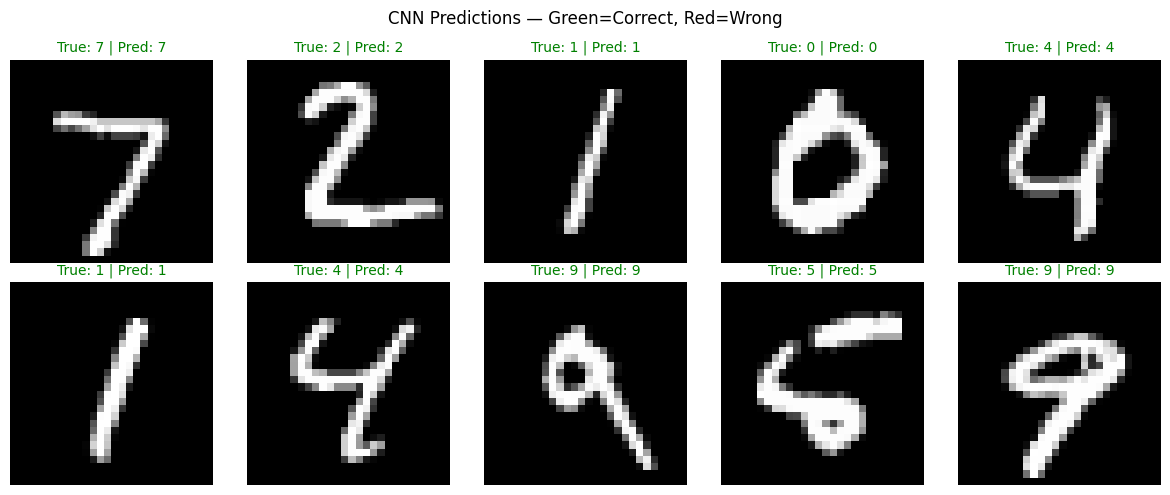

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()
images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs     = model(images)
    _, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()
    ax.imshow(img, cmap="gray")
    color = "green" if predicted[i]==labels[i] else "red"
    ax.set_title(
        f"True: {labels[i]} | Pred: {predicted[i]}",
        color=color, fontsize=10)
    ax.axis("off")

plt.suptitle("CNN Predictions — Green=Correct, Red=Wrong",
             fontsize=12)
plt.tight_layout()
plt.show()